# Spatial segregation of valence neurons (LDA + SVM)

This notebook tests whether **positive vs negative valence neurons** are **spatially segregated** within brain areas.

We compare:
- **LDA** (linear, interpretable axis)
- **SVM (RBF)** with **none/downsample/upsample** balancing

Outputs:
- Per-area **CV accuracy** and **CV AUC**
- **Fisher ratio** and **LDA axis direction**
- **Permutation p-values** (AUC)
- CSVs in `OUTPUT_DIR`

In [1]:
# --- Imports ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Setup & configuration

Update file paths and parameters here.

## Notes

- Consider SVM hyperparameter tuning (`C`, `gamma`) if you want the best achievable accuracy per area.
- If your coordinate convention is not `[z, y, x]`, change the unpacking in `load_valence_table()`.

In [2]:
POS_CSV = '/Volumes/LaCie/larval_HuC/imaging/7dpf_positive_correlations_25s_no_HCl_1000_corrected.csv'
NEG_CSV = '/Volumes/LaCie/larval_HuC/imaging/7dpf_negative_correlations_25s_no_HCl_1000_corrected.csv'

# Area selection: str, list[str], or 'auto'
AREAS = 'olfactory_bulb'

P_FDR_THRESH = 0.05
MIN_PER_CLASS = 20

CV_FOLDS = 5
RANDOM_STATE = 42

N_PERMUTATIONS = 1000  

OUTPUT_DIR = './spatial_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ---- Plot configuration (paper style) ----
PLOT_LDA_KDE = True  # reproduce original LDA KDE projection plot
# Permute axes in the 3D plot to change orientation, e.g. ('y','x','z') or ('z','y','x')
PLOT_AXES_3D = ('x','y','z')
VIEW_ELEV = 15
VIEW_AZIM = 45

# SVM slice plot configuration
SVM_FIXED_AXIS = 'x'      # slice normal axis: 'x'/'y'/'z'
SVM_PLOT_AXES = ('y','z') # axes shown in the 2D slice
SVM_MARGIN = 10
SVM_FIXED_VALUE = None    # None -> median along fixed axis


## Helper functions

In [3]:

def _safe_parse_coords(x):
    """Parse a coordinate field to a 3-tuple.

    Accepts list/tuple/ndarray, or a string representation of a list/tuple.
    """
    import ast
    import numpy as np

    if isinstance(x, (list, tuple, np.ndarray)):
        coords = list(x)
    elif isinstance(x, str):
        coords = list(ast.literal_eval(x))
    else:
        raise ValueError(f"Unsupported coords type: {type(x)}")

    if len(coords) != 3:
        raise ValueError(f"Expected 3D coords, got length {len(coords)}: {coords}")

    return tuple(coords)


def load_valence_table(pos_csv: str, neg_csv: str):
    """Load positive/negative neuron tables and concatenate into a single DataFrame."""
    import pandas as pd

    pos = pd.read_csv(pos_csv).copy()
    neg = pd.read_csv(neg_csv).copy()
    pos["valence"] = 1
    neg["valence"] = 0
    df = pd.concat([pos, neg], ignore_index=True)

    if "coords" not in df.columns:
        raise KeyError("Expected a 'coords' column in the input CSVs.")

    df["coords_parsed"] = df["coords"].apply(_safe_parse_coords)

    # Original notebook unpacked coords as [z, y, x]
    df[["z", "y", "x"]] = pd.DataFrame(df["coords_parsed"].tolist(), index=df.index)
    return df


def filter_area(df, area: str, p_fdr_thresh: float = 0.05):
    """Return (valence_neurons, nonvalence_neurons) within a given area."""
    area_df = df[df["area"] == area].copy()
    valence_neurons = area_df[area_df["p_fdr"] < p_fdr_thresh].copy()
    nonvalence_neurons = area_df[area_df["p_fdr"] >= p_fdr_thresh].copy()
    return valence_neurons, nonvalence_neurons


def balance_classes(df, label_col: str = "valence", strategy=None, random_state: int = 42):
    """Balance classes by downsampling majority or upsampling minority."""
    import pandas as pd
    from sklearn.utils import resample

    if strategy is None:
        return df.copy()

    pos = df[df[label_col] == 1]
    neg = df[df[label_col] == 0]

    if len(pos) == 0 or len(neg) == 0:
        return df.copy()

    if strategy == "downsample":
        n = min(len(pos), len(neg))
        pos_bal = resample(pos, replace=False, n_samples=n, random_state=random_state)
        neg_bal = resample(neg, replace=False, n_samples=n, random_state=random_state)
        out = pd.concat([pos_bal, neg_bal], ignore_index=True)

    elif strategy == "upsample":
        n = max(len(pos), len(neg))
        pos_bal = resample(pos, replace=True, n_samples=n, random_state=random_state)
        neg_bal = resample(neg, replace=True, n_samples=n, random_state=random_state)
        out = pd.concat([pos_bal, neg_bal], ignore_index=True)

    else:
        raise ValueError("strategy must be one of {None, 'downsample', 'upsample'}")

    return out.sample(frac=1, random_state=random_state).reset_index(drop=True)


def evaluate_lda_separation(
    df,
    coord_cols=("x", "y", "z"),
    label_col="valence",
    cv_folds: int = 5,
    random_state: int = 42,
    plot: bool = False,
    title: str = "",
    output_dir: str | None = None,
    save_name: str | None = None,
):
    """LDA separation with CV accuracy/AUC + Fisher ratio + LDA direction.

    If plot=True, reproduces the original notebook's KDE projection plot style.
    """
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.model_selection import StratifiedKFold, cross_val_score
    from sklearn.pipeline import make_pipeline
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    from sklearn.linear_model import LogisticRegression

    X = df[list(coord_cols)].values
    y = df[label_col].values

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    pipe = make_pipeline(
        LinearDiscriminantAnalysis(n_components=1),
        LogisticRegression(max_iter=1000),
    )

    acc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    auc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

    # Refit LDA for full projection + direction (for plotting + interpretability)
    lda = LinearDiscriminantAnalysis(n_components=1)
    proj = lda.fit_transform(X, y).ravel()

    lda_vec = lda.coef_[0]
    lda_vec = lda_vec / (np.linalg.norm(lda_vec) + 1e-12)

    mean_pos = proj[y == 1].mean()
    mean_neg = proj[y == 0].mean()
    var_pos = proj[y == 1].var()
    var_neg = proj[y == 0].var()
    fisher_ratio = (mean_pos - mean_neg) ** 2 / (var_pos + var_neg + 1e-12)

    results = {
        "accuracy_mean": float(acc_scores.mean()),
        "accuracy_std": float(acc_scores.std()),
        "auc_mean": float(auc_scores.mean()),
        "auc_std": float(auc_scores.std()),
        "fisher_ratio": float(fisher_ratio),
        "lda_vector_x": float(lda_vec[0]),
        "lda_vector_y": float(lda_vec[1]),
        "lda_vector_z": float(lda_vec[2]),
    }

    if plot:
        proj_df = pd.DataFrame({"lda_proj": proj, "valence": y})

        plt.figure(figsize=(6, 4))
        sns.kdeplot(
            data=proj_df,
            x="lda_proj",
            hue="valence",
            palette={0: "magenta", 1: "green"},
            fill=True,
            common_norm=False,
        )

        plt.title(f"LDA Separation - {title}", fontsize=20)
        plt.xlabel("LDA Projection", fontsize=20)
        plt.ylabel("Density", fontsize=20)

        label_text = (
            f"AUC: {results['auc_mean']:.2f} ± {results['auc_std']:.2f}\n"
            f"Acc: {results['accuracy_mean']:.2f} ± {results['accuracy_std']:.2f}\n"
            f"Fisher: {results['fisher_ratio']:.2f}"
        )

        ax = plt.gca()
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        ax.text(
            0.95,
            0.95,
            label_text,
            transform=ax.transAxes,
            fontsize=12,
            color="black",
            ha="right",
            va="top",
        )

        plt.tight_layout()
        plt.xticks(fontsize=20)
        plt.yticks(fontsize=20)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        for spine in ax.spines.values():
            spine.set_linewidth(2)

        # Save (parameterized; no hardcoded user paths)
        if output_dir is not None:
            os.makedirs(output_dir, exist_ok=True)
            fname = save_name or f"{title}_LDA_projection_KDE.svg"
            fname = fname.replace(" ", "_")
            outpath = os.path.join(output_dir, fname)
            plt.savefig(outpath, format="svg", dpi=300, bbox_inches="tight")

        plt.show()

    return results


def evaluate_svm_separation(df, balance=None, coord_cols=("x","y","z"), label_col="valence", cv_folds: int = 5, random_state: int = 42):
    """SVM (RBF) separation with optional balancing."""
    from sklearn.model_selection import StratifiedKFold, cross_val_score
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.svm import SVC

    df_bal = balance_classes(df, label_col=label_col, strategy=balance, random_state=random_state)

    X = df_bal[list(coord_cols)].values
    y = df_bal[label_col].values

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    pipe = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", probability=True, random_state=random_state)
    )

    acc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    auc_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

    return {
        "balance": balance if balance is not None else "none",
        "n_total": int(len(df_bal)),
        "n_pos": int((df_bal[label_col] == 1).sum()),
        "n_neg": int((df_bal[label_col] == 0).sum()),
        "accuracy_mean": float(acc_scores.mean()),
        "accuracy_std": float(acc_scores.std()),
        "auc_mean": float(auc_scores.mean()),
        "auc_std": float(auc_scores.std()),
    }


def permutation_test_auc(df, method: str, balance=None, coord_cols=("x","y","z"), label_col="valence",
                         cv_folds: int = 5, n_perm: int = 500, random_state: int = 42):
    """Permutation test on cross-validated AUC (one-sided: perm >= observed)."""
    import numpy as np
    from sklearn.model_selection import StratifiedKFold, cross_val_score
    from sklearn.pipeline import make_pipeline
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.svm import SVC

    rng = np.random.default_rng(random_state)

    if method == "lda":
        obs = evaluate_lda_separation(df, coord_cols, label_col, cv_folds, random_state)["auc_mean"]
        X = df[list(coord_cols)].values
        y = df[label_col].values
        pipe = make_pipeline(LinearDiscriminantAnalysis(n_components=1), LogisticRegression(max_iter=1000))
    elif method == "svm":
        df_bal = balance_classes(df, label_col=label_col, strategy=balance, random_state=random_state)
        obs = evaluate_svm_separation(df, balance, coord_cols, label_col, cv_folds, random_state)["auc_mean"]
        X = df_bal[list(coord_cols)].values
        y = df_bal[label_col].values
        pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=random_state))
    else:
        raise ValueError("method must be 'lda' or 'svm'")

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    perm_aucs = []
    for _ in range(int(n_perm)):
        y_perm = rng.permutation(y)
        auc_scores = cross_val_score(pipe, X, y_perm, cv=cv, scoring="roc_auc")
        perm_aucs.append(auc_scores.mean())

    perm_aucs = np.array(perm_aucs)
    p = (np.sum(perm_aucs >= obs) + 1) / (len(perm_aucs) + 1)

    return {"observed_auc": float(obs), "p_value": float(p), "perm_aucs": perm_aucs}


def angles_to_axes(vec_xyz):
    """Angles (degrees) between vec_xyz and x/y/z axes."""
    import numpy as np
    v = np.array(vec_xyz, dtype=float)
    v = v / (np.linalg.norm(v) + 1e-12)
    axes = {"x": np.array([1,0,0]), "y": np.array([0,1,0]), "z": np.array([0,0,1])}
    out = {}
    for k, a in axes.items():
        cosang = float(np.clip(np.dot(v, a), -1, 1))
        out[f"angle_to_{k}"] = float(np.degrees(np.arccos(cosang)))
    return out



def plot_lda_projection_paper(df, title='', coord_cols=('x','y','z'), label_col='valence'):
    """Match the original notebook's LDA projection histogram style."""
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

    X = df[list(coord_cols)].values
    y = df[label_col].values

    lda = LinearDiscriminantAnalysis(n_components=1)
    X_lda = lda.fit_transform(X, y).ravel()

    plt.figure(figsize=(6,4))
    plt.hist(X_lda[y==1], bins=30, alpha=0.6, color='green', label='Positive')
    plt.hist(X_lda[y==0], bins=30, alpha=0.6, color='magenta', label='Negative')
    plt.axvline(0, color='black', linestyle='--', label='Decision boundary')
    plt.xlabel('LDA Projection Value')
    plt.ylabel('Neuron Count')
    if title:
        plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def _axis_index_map(plot_axes=('x','y','z')):
    """Return indices mapping plot axes -> data axes."""
    axes = {'x':0, 'y':1, 'z':2}
    return [axes[a] for a in plot_axes]


def plot_basic_3d_scatter_paper(valence_neurons, nonvalence_neurons=None, plot_axes=('x','y','z')):
    """Match the original notebook's basic 3D scatter style (cell 8)."""
    import matplotlib.pyplot as plt
    import numpy as np

    idx = _axis_index_map(plot_axes)

    def sel(df):
        return df[['x','y','z']].values[:, idx]

    X_pos = sel(valence_neurons[valence_neurons['valence'] == 1])
    X_neg = sel(valence_neurons[valence_neurons['valence'] == 0])
    X_other = sel(nonvalence_neurons) if (nonvalence_neurons is not None and len(nonvalence_neurons)>0) else None

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    if X_other is not None:
        ax.scatter(X_other[:, 0], X_other[:, 1], X_other[:, 2],
                   color='lightgray', alpha=0.1, s=10, label='Non-valence')

    ax.scatter(X_pos[:, 0], X_pos[:, 1], X_pos[:, 2],
               color='green', alpha=1, s=20, label='Positive')
    ax.scatter(X_neg[:, 0], X_neg[:, 1], X_neg[:, 2],
               color='magenta', alpha=1, s=20, label='Negative')

    ax.set_xlabel(plot_axes[0].upper())
    ax.set_ylabel(plot_axes[1].upper())
    ax.set_zlabel(plot_axes[2].upper())
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_lda_axis_plane_3d_paper(valence_neurons, lda_vector_xyz, title='LDA Axis Separating Valence Neurons',
                                plot_axes=('x','y','z'), elev=15, azim=45,
                                plane_size=80, plane_grid_n=10,
                                arrow_len=50,
                                savepath=None):
    """Recreate the original paper-style 3D plot with bidirectional arrow + separation plane.

    plot_axes lets you permute which data axis appears on X/Y/Z in the *plot* (e.g. ('y','x','z')).
    elev/azim control the viewpoint.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import proj3d
    from matplotlib.patches import FancyArrowPatch

    # --- mapping (data -> plot) ---
    idx = _axis_index_map(plot_axes)

    def reorder_vec(v):
        v = np.asarray(v, dtype=float)
        return v[idx]

    def reorder_points(P):
        P = np.asarray(P, dtype=float)
        return P[:, idx]

    X = reorder_points(valence_neurons[['x','y','z']].values)
    y = valence_neurons['valence'].values

    lda_vector_plot = reorder_vec(lda_vector_xyz)
    lda_vector_plot = lda_vector_plot / (np.linalg.norm(lda_vector_plot) + 1e-12)

    class Arrow3D(FancyArrowPatch):
        def __init__(self, xs, ys, zs, *args, **kwargs):
            super().__init__((0, 0), (0, 0), *args, **kwargs)
            self._verts3d = xs, ys, zs

        def draw(self, renderer):
            xs3d, ys3d, zs3d = self._verts3d
            xs, ys, _ = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
            self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
            super().draw(renderer)

        def do_3d_projection(self):
            return 0

    centroid = X.mean(axis=0)

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], X[y == 1][:, 2],
               c='green', alpha=0.5, label='Positive')
    ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], X[y == 0][:, 2],
               c='magenta', alpha=0.5, label='Negative')

    # Bidirectional arrow along LDA axis
    start = centroid - lda_vector_plot * arrow_len
    end   = centroid + lda_vector_plot * arrow_len

    arrow_fwd = Arrow3D([start[0], end[0]],
                        [start[1], end[1]],
                        [start[2], end[2]],
                        mutation_scale=20, lw=2, arrowstyle='-|>', color='black')
    ax.add_artist(arrow_fwd)

    arrow_rev = Arrow3D([end[0], start[0]],
                        [end[1], start[1]],
                        [end[2], start[2]],
                        mutation_scale=20, lw=2, arrowstyle='-|>', color='black')
    ax.add_artist(arrow_rev)

    # Separation plane computed from class centroids (in plot coordinates)
    pos = X[y == 1]
    neg = X[y == 0]
    pos_centroid = pos.mean(axis=0)
    neg_centroid = neg.mean(axis=0)
    midpoint = (pos_centroid + neg_centroid) / 2
    normal = lda_vector_plot

    def orthonormal_basis(normal):
        if abs(normal[0]) < abs(normal[1]):
            v = np.array([1, 0, 0])
        else:
            v = np.array([0, 1, 0])
        v1 = np.cross(normal, v)
        v1 = v1 / (np.linalg.norm(v1) + 1e-12)
        v2 = np.cross(normal, v1)
        v2 = v2 / (np.linalg.norm(v2) + 1e-12)
        return v1, v2

    v1, v2 = orthonormal_basis(normal)
    grid_range = np.linspace(-plane_size, plane_size, plane_grid_n)
    xx, yy = np.meshgrid(grid_range, grid_range)
    plane_points = midpoint.reshape(3, 1, 1) + v1.reshape(3, 1, 1)*xx + v2.reshape(3, 1, 1)*yy
    X_plane, Y_plane, Z_plane = plane_points
    ax.plot_surface(X_plane, Y_plane, Z_plane, color='gray', alpha=0.3, edgecolor='none')

    # Axis-angle labels (computed in *data* space, but attached to the axis that displays that data dimension)
    lda_vec_data = np.asarray(lda_vector_xyz, dtype=float)
    lda_vec_data = lda_vec_data / (np.linalg.norm(lda_vec_data) + 1e-12)

    axes_data = {'x': np.array([1,0,0]), 'y': np.array([0,1,0]), 'z': np.array([0,0,1])}
    axis_angles = {k: np.degrees(np.arccos(np.clip(np.dot(lda_vec_data, v), -1, 1))) for k, v in axes_data.items()}

    axis_text = {
        'x': 'X μm (L–M)',
        'y': 'Y μm (A–P)',
        'z': 'Z μm (D–V)',
    }

    ax.set_xlabel(f"{axis_text[plot_axes[0]]}\n{axis_angles[plot_axes[0]]:.0f}° to LDA", fontsize=15)
    ax.set_ylabel(f"{axis_text[plot_axes[1]]}\n{axis_angles[plot_axes[1]]:.0f}° to LDA", fontsize=15)
    ax.set_zlabel(f"{axis_text[plot_axes[2]]}\n{axis_angles[plot_axes[2]]:.0f}° to LDA", fontsize=16)

    # Sparse ticks (every other)
    ax.set_xticks(ax.get_xticks()[::2])
    ax.set_yticks(ax.get_yticks()[::2])
    ax.set_zticks(ax.get_zticks()[::2])

    ax.xaxis.labelpad = 20
    ax.yaxis.labelpad = 20
    ax.zaxis.labelpad = 10
    ax.tick_params(axis='both', which='major', labelsize=14, width=1)

    ax.set_title(title, fontsize=21, ha='center')
    ax.view_init(elev=elev, azim=azim)

    if savepath is not None:
        plt.savefig(savepath, format=os.path.splitext(savepath)[1].lstrip('.'), dpi=300, bbox_inches='tight')

    plt.show()


def plot_svm_decision_boundary_slice_paper(valence_neurons, balance='downsample',
                                          fixed_axis='x', fixed_value=None, margin=10,
                                          plot_axes=('y','z'),
                                          title_prefix='SVM Decision Boundary',
                                          random_state=42,
                                          savepath=None):
    """Recreate the original notebook's 2D SVM slice plot style (cells 14/15).

    fixed_axis: which axis to slice along ('x'/'y'/'z')
    plot_axes: the two axes to display in the 2D plot (default YZ)
    fixed_value: if None, uses median on fixed_axis (plus 0 offset)
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.model_selection import StratifiedKFold, cross_val_score
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.svm import SVC

    # balance
    df_bal = balance_classes(valence_neurons, label_col='valence', strategy=balance, random_state=random_state)
    X_bal = df_bal[['x','y','z']].values
    y_bal = df_bal['valence'].values

    pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, random_state=random_state))
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    auc_scores = cross_val_score(pipeline, X_bal, y_bal, cv=cv, scoring='roc_auc')
    acc_scores = cross_val_score(pipeline, X_bal, y_bal, cv=cv, scoring='accuracy')
    auc_mean, auc_std = auc_scores.mean(), auc_scores.std()
    acc_mean, acc_std = acc_scores.mean(), acc_scores.std()

    pipeline.fit(X_bal, y_bal)

    ax_to_i = {'x':0,'y':1,'z':2}
    fi = ax_to_i[fixed_axis]
    p0 = ax_to_i[plot_axes[0]]
    p1 = ax_to_i[plot_axes[1]]

    if fixed_value is None:
        fixed_value = float(np.median(X_bal[:, fi]))

    # mask slice
    distances = np.abs(X_bal[:, fi] - fixed_value)
    in_margin = distances < margin

    # grid over plot axes at fixed axis value
    a0_range = np.linspace(X_bal[:, p0].min(), X_bal[:, p0].max(), 100)
    a1_range = np.linspace(X_bal[:, p1].min(), X_bal[:, p1].max(), 100)
    A0, A1 = np.meshgrid(a0_range, a1_range)

    grid = np.zeros((A0.size, 3), dtype=float)
    grid[:, fi] = fixed_value
    grid[:, p0] = A0.ravel()
    grid[:, p1] = A1.ravel()

    probs = pipeline.predict_proba(grid)[:, 1].reshape(A0.shape)

    plt.figure(figsize=(8, 6))
    contour = plt.contourf(A0, A1, probs, levels=np.linspace(0, 1, 21), cmap='coolwarm', alpha=0.7)
    cbar = plt.colorbar(contour)
    cbar.set_label('P (Positive)', fontsize=25, labelpad=15)
    cbar.ax.tick_params(labelsize=20)

    # alpha based on distance to slice plane (matches original logic)
    normalized = 1 - np.clip(distances / margin, 0, 1)
    alphas = 0.2 + 0.6 * normalized

    for val, color, label in zip([1, 0], ['green', 'magenta'], ['Positive', 'Negative']):
        m = y_bal == val
        plt.scatter(X_bal[m][:, p0], X_bal[m][:, p1],
                    color=color, s=30, alpha=alphas[m], label=label)

    text = f"AUC: {auc_mean:.2f} ± {auc_std:.2f}\nAcc: {acc_mean:.2f} ± {acc_std:.2f}"
    plt.text(0.05, 0.95, text,
             transform=plt.gca().transAxes,
             fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.contour(A0, A1, probs, levels=[0.5], colors='black', linewidths=2)

    axis_text = {
        'x': 'X μm (L–M)',
        'y': 'Y μm (A–P)',
        'z': 'Z μm (D–V)',
    }
    plt.xlabel(axis_text[plot_axes[0]], fontsize=23)
    plt.ylabel(axis_text[plot_axes[1]], fontsize=23)

    ax = plt.gca()
    ax.tick_params(axis='both', which='major', labelsize=15, width=1)

    plt.title(f"{title_prefix}\n ({plot_axes[0].upper()}{plot_axes[1].upper()} slice @ {fixed_axis.upper()}={fixed_value:.1f})", fontsize=18, pad=20)
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, format=os.path.splitext(savepath)[1].lstrip('.'), dpi=300, bbox_inches='tight')

    plt.show()



def plot_method_comparison(results_df, area: str):
    """Bar plot of CV AUC across methods for one area."""
    import matplotlib.pyplot as plt

    sub = results_df[results_df['area'] == area].copy().sort_values('auc_mean', ascending=False)
    plt.figure(figsize=(7,4))
    plt.bar(sub['method'], sub['auc_mean'])
    plt.ylabel('CV AUC')
    plt.title(f"Method comparison (AUC) — {area}")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


## Load data

In [4]:
valence = load_valence_table(POS_CSV, NEG_CSV)
print('Loaded:', valence.shape)
print('Unique areas:', valence['area'].nunique())
valence.head()

Loaded: (400232, 14)
Unique areas: 39


,Unnamed: 0.1,Unnamed: 0,correlation,coords,area,fish_id,neuron_id,p_value,p_fdr,valence,coords_parsed,z,y,x
0,0,0,-0.215531,"[251.66357421875, 217.15609741210938, 354.3086...",dorsal_habenula,230713_fb,0_fb,0.670,0.915525,1,"(251.66357421875, 217.15609741210938, 354.3086...",251.663574,217.156097,354.308655
1,1,1,0.011484,"[239.10096740722656, 207.85594177246094, 260.6...",pallium,230713_fb,1000_fb,0.262,0.567102,1,"(239.10096740722656, 207.85594177246094, 260.6...",239.100967,207.855942,260.654449
2,2,2,0.015778,"[238.01873779296875, 229.09092712402344, 334.8...",dorsal_habenula,230713_fb,1001_fb,0.013,0.168397,1,"(238.01873779296875, 229.09092712402344, 334.8...",238.018738,229.090927,334.800842
3,3,3,-0.103653,"[236.69760131835938, 295.0842590332031, 269.88...",pretectum,230713_fb,1002_fb,0.705,0.939579,1,"(236.69760131835938, 295.0842590332031, 269.88...",236.697601,295.084259,269.881531
4,4,4,-0.095127,"[237.74826049804688, 212.12896728515625, 368.9...",pallium,230713_fb,1003_fb,0.036,0.244267,1,"(237.74826049804688, 212.12896728515625, 368.9...",237.748260,212.128967,368.969666


## Select areas to analyze

In [5]:
if isinstance(AREAS, str) and AREAS.lower() == 'auto':
    areas_to_run = []
    for a in sorted(valence['area'].dropna().unique()):
        v, _ = filter_area(valence, a, p_fdr_thresh=P_FDR_THRESH)
        n_pos = (v['valence'] == 1).sum()
        n_neg = (v['valence'] == 0).sum()
        if (n_pos >= MIN_PER_CLASS) and (n_neg >= MIN_PER_CLASS):
            areas_to_run.append(a)
elif isinstance(AREAS, str):
    areas_to_run = [AREAS]
else:
    areas_to_run = list(AREAS)

print(f'Running {len(areas_to_run)} area(s):')
print(areas_to_run)

Running 1 area(s):
['olfactory_bulb']


## Run analysis per area (LDA + SVM + permutation tests)

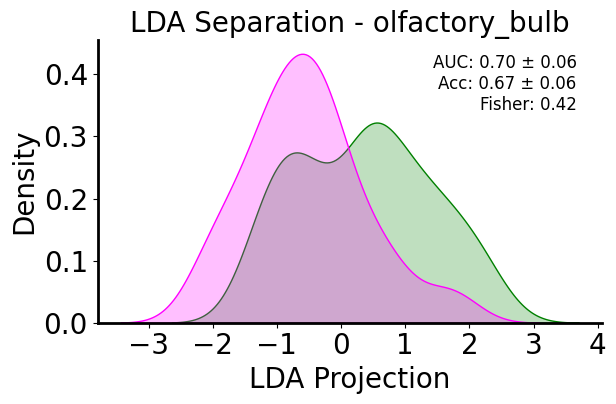

Saved:
 - ./spatial_outputs/spatial_method_results.csv
 - ./spatial_outputs/spatial_permutation_pvalues.csv


,area,method,n_pos,n_neg,accuracy_mean,accuracy_std,auc_mean,auc_std,fisher_ratio,lda_vector_x,lda_vector_y,lda_vector_z,angle_to_x,angle_to_y,angle_to_z,n_total
0,olfactory_bulb,lda,92,58,0.666667,0.063246,0.700474,0.064636,0.420201,0.031626,0.396121,-0.917654,88.187652,66.664117,156.585437,NaN
1,olfactory_bulb,svm_none,92,58,0.700000,0.059628,0.683218,0.073615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.0
2,olfactory_bulb,svm_downsample,58,58,0.603261,0.034027,0.649242,0.045303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,116.0
3,olfactory_bulb,svm_upsample,92,92,0.738889,0.090555,0.803606,0.089976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,184.0


In [6]:
all_results = []
all_perm = []

for area in areas_to_run:
    val_neurons, nonval_neurons = filter_area(valence, area, p_fdr_thresh=P_FDR_THRESH)
    n_pos = int((val_neurons['valence'] == 1).sum())
    n_neg = int((val_neurons['valence'] == 0).sum())

    if (n_pos < 2) or (n_neg < 2):
        print(f'[SKIP] {area}: too few neurons after filtering (pos={n_pos}, neg={n_neg})')
        continue

    if (n_pos < MIN_PER_CLASS) or (n_neg < MIN_PER_CLASS):
        print(f'[WARN] {area}: small class sizes (pos={n_pos}, neg={n_neg}) — results may be noisy.')

    # LDA
    lda_res = evaluate_lda_separation(val_neurons, cv_folds=CV_FOLDS, random_state=RANDOM_STATE, plot=PLOT_LDA_KDE, title=area, output_dir=OUTPUT_DIR)
    lda_vec = np.array([lda_res['lda_vector_x'], lda_res['lda_vector_y'], lda_res['lda_vector_z']])
    lda_angles = angles_to_axes(lda_vec)

    all_results.append({
        'area': area,
        'method': 'lda',
        'n_pos': n_pos,
        'n_neg': n_neg,
        **lda_res,
        **lda_angles,
    })

    # SVM: none/down/up
    for bal in [None, 'downsample', 'upsample']:
        svm_res = evaluate_svm_separation(val_neurons, balance=bal, cv_folds=CV_FOLDS, random_state=RANDOM_STATE)
        all_results.append({
            'area': area,
            'method': f"svm_{svm_res['balance']}",
            'n_pos': n_pos,
            'n_neg': n_neg,
            **{k: v for k, v in svm_res.items() if k != 'balance'},
        })

    # Permutation tests (AUC)
    if N_PERMUTATIONS and N_PERMUTATIONS > 0:
        perm_lda = permutation_test_auc(val_neurons, method='lda', n_perm=N_PERMUTATIONS,
                                        cv_folds=CV_FOLDS, random_state=RANDOM_STATE)
        all_perm.append({'area': area, 'method': 'lda', 'observed_auc': perm_lda['observed_auc'], 'p_value': perm_lda['p_value']})

        for bal in [None, 'downsample', 'upsample']:
            perm_svm = permutation_test_auc(val_neurons, method='svm', balance=bal, n_perm=N_PERMUTATIONS,
                                            cv_folds=CV_FOLDS, random_state=RANDOM_STATE)
            all_perm.append({'area': area, 'method': f"svm_{bal if bal else 'none'}",
                             'observed_auc': perm_svm['observed_auc'], 'p_value': perm_svm['p_value']})

results_df = pd.DataFrame(all_results)
perm_df = pd.DataFrame(all_perm)

results_path = os.path.join(OUTPUT_DIR, 'spatial_method_results.csv')
perm_path = os.path.join(OUTPUT_DIR, 'spatial_permutation_pvalues.csv')

results_df.to_csv(results_path, index=False)
perm_df.to_csv(perm_path, index=False)

print('Saved:')
print(' -', results_path)
print(' -', perm_path)

results_df.head()

## Quick plots (optional)

,area,method,n_pos,n_neg,accuracy_mean,accuracy_std,auc_mean,auc_std,fisher_ratio,lda_vector_x,lda_vector_y,lda_vector_z,angle_to_x,angle_to_y,angle_to_z,n_total
3,olfactory_bulb,svm_upsample,92,92,0.738889,0.090555,0.803606,0.089976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,184.0
0,olfactory_bulb,lda,92,58,0.666667,0.063246,0.700474,0.064636,0.420201,0.031626,0.396121,-0.917654,88.187652,66.664117,156.585437,NaN
1,olfactory_bulb,svm_none,92,58,0.700000,0.059628,0.683218,0.073615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.0
2,olfactory_bulb,svm_downsample,58,58,0.603261,0.034027,0.649242,0.045303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,116.0


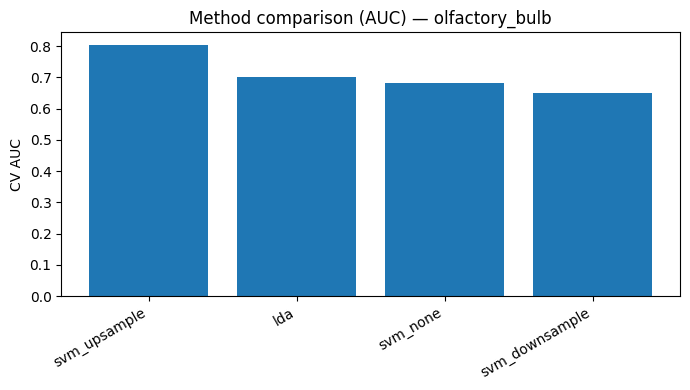

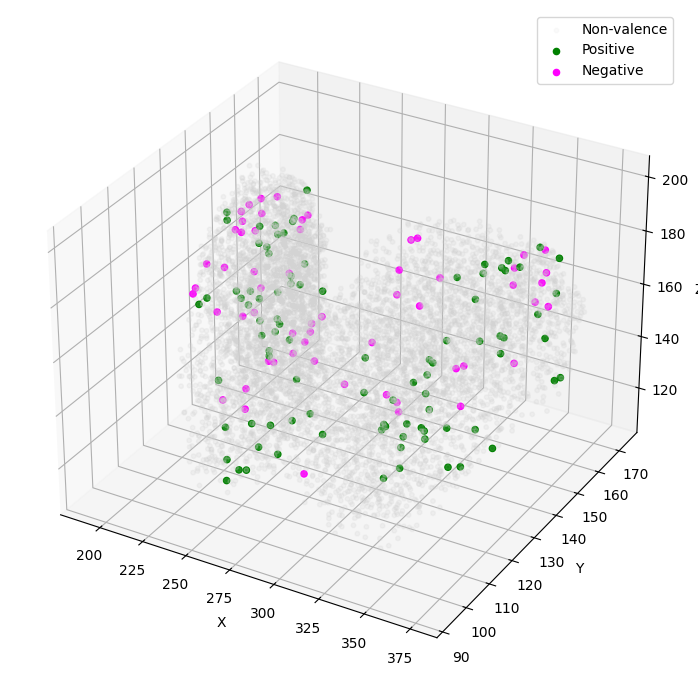

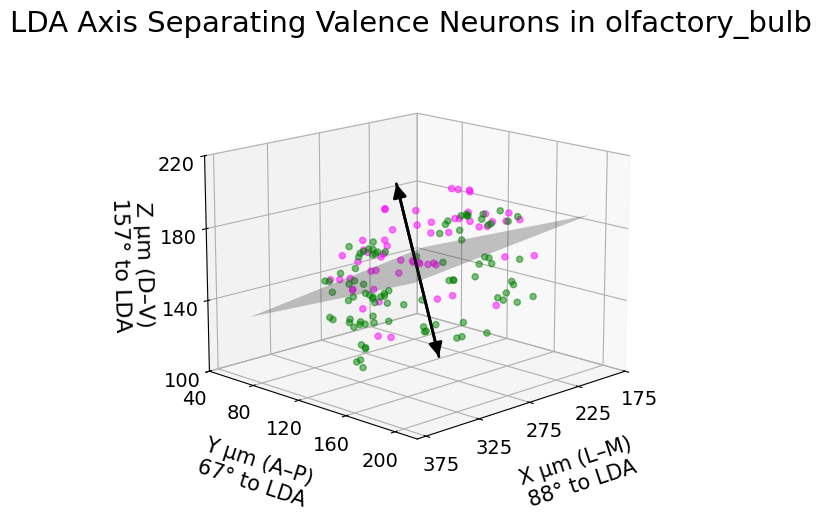

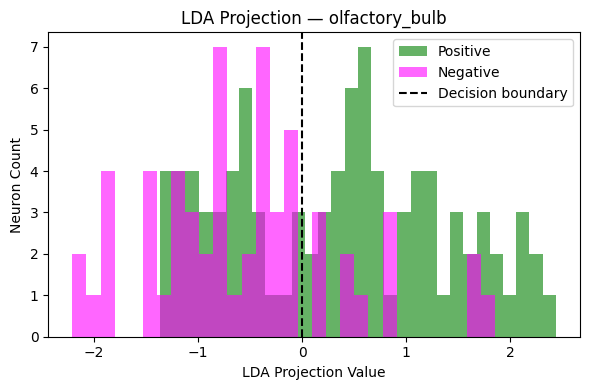

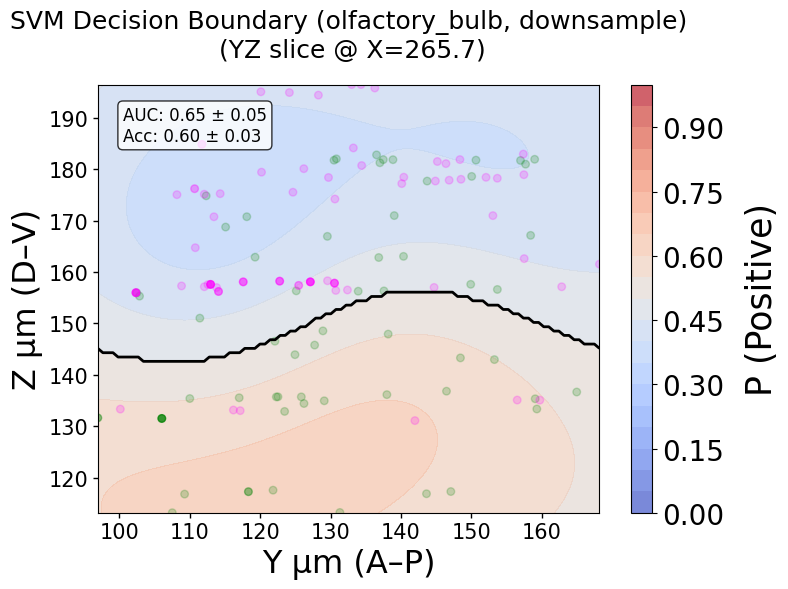

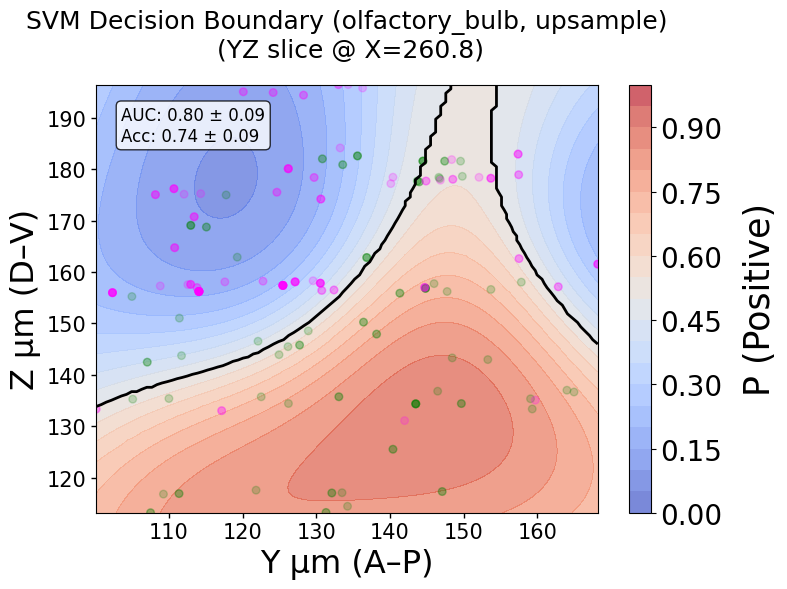

In [7]:
if len(results_df) > 0:
    area0 = results_df['area'].iloc[0]
    display(results_df[results_df['area'] == area0].sort_values('auc_mean', ascending=False))
    plot_method_comparison(results_df, area0)

    # --- Pull neurons for the example area ---
    val_neurons, nonval_neurons = filter_area(valence, area0, p_fdr_thresh=P_FDR_THRESH)

    # --- LDA vector (full fit) for visualization ---
    lda_row = results_df[(results_df['area'] == area0) & (results_df['method'] == 'lda')].iloc[0]
    lda_vec = np.array([lda_row['lda_vector_x'], lda_row['lda_vector_y'], lda_row['lda_vector_z']])

    # --- Paper-style plots reproduced from the original notebook ---
    plot_basic_3d_scatter_paper(val_neurons, nonval_neurons, plot_axes=PLOT_AXES_3D)
    plot_lda_axis_plane_3d_paper(
        val_neurons,
        lda_vector_xyz=lda_vec,
        title=f"LDA Axis Separating Valence Neurons in {area0}",
        plot_axes=PLOT_AXES_3D,
        elev=VIEW_ELEV,
        azim=VIEW_AZIM,
        savepath=None,  # set to a .svg or .png path if you want saved outputs
    )
    plot_lda_projection_paper(val_neurons, title=f"LDA Projection — {area0}")

    # SVM decision boundary slices (downsample + upsample) in the original style
    plot_svm_decision_boundary_slice_paper(
        val_neurons,
        balance='downsample',
        fixed_axis=SVM_FIXED_AXIS,
        fixed_value=SVM_FIXED_VALUE,
        margin=SVM_MARGIN,
        plot_axes=SVM_PLOT_AXES,
        title_prefix=f"SVM Decision Boundary ({area0}, downsample)"
    )

    plot_svm_decision_boundary_slice_paper(
        val_neurons,
        balance='upsample',
        fixed_axis=SVM_FIXED_AXIS,
        fixed_value=SVM_FIXED_VALUE,
        margin=SVM_MARGIN,
        plot_axes=SVM_PLOT_AXES,
        title_prefix=f"SVM Decision Boundary ({area0}, upsample)"
    )
